# Assignment Sesi 17
Nama: Faraday Barr Fatahillah

**Instruksi**\
Anda baru bergabung sebagai data analyst di perusahaan agen properti Melbourne. Tim riset menyerahkan dataset mentah hasil scraping dari situs listing properti. Sebelum data ini bisa dipakai untuk membangun model prediksi harga, Anda diminta membersihkan dan mempersiapkannya secara sistematis.

Dataset: https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market

In [299]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from scipy.stats import zscore

**Task 1 — Audit Data Awal dan Baseline**\
1. Load dataset dan cetak shape serta nama semua kolom.
2. Untuk setiap kolom, hitung persentase missing values dan tampilkan hasilnya sebagai dataframe yang diurutkan dari persentase tertinggi. Format kolom output: Column, Missing Count, Missing Pct (%).
3. Drop baris yang kolom Price-nya kosong karena ini adalah target.
4. Identifikasi kolom kategorikal dan tampilkan jumlah unique value (nunique) setiap kolom. Beri keterangan mana yang termasuk HIGH CARDINALITY (lebih dari 15 nilai unik) di cell markdown.
5. Untuk baseline: gunakan hanya 3 kolom numerik (Rooms, Landsize, BuildingArea). Drop baris yang masih ada missing values pada ketiga kolom tersebut. Latih LinearRegression dengan 5-fold CV (scoring='r2'). Cetak rata-rata dan standar deviasi skor CV.

In [300]:
#Task 1.1   
df = pd.read_csv('Melbourne_housing_FULL.csv')

df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,2.0,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,3.0,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [301]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  str    
 1   Address        34857 non-null  str    
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  str    
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  str    
 6   SellerG        34857 non-null  str    
 7   Date           34857 non-null  str    
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  str    
 17  Lattitude      26881 non-null  float64
 18  Longtitude     26

In [302]:
#Task 1.2
missing_count = df.isna().sum()
missing_pct = (missing_count/len(df))*100

missing_df =(
    pd.DataFrame({
        'Column': missing_count.index,
        'Missing_Count': missing_count.values,
        'Missing_PCT': missing_pct.values 
    }).reset_index(drop=True).sort_values(by='Missing_PCT', ascending=False)
) 

missing_df

,Column,Missing_Count,Missing_PCT
14,BuildingArea,21115,60.576068
15,YearBuilt,19306,55.386293
13,Landsize,11810,33.881286
12,Car,8728,25.039447
11,Bathroom,8226,23.599277
10,Bedroom2,8217,23.573457
17,Lattitude,7976,22.882061
18,Longtitude,7976,22.882061
4,Price,7610,21.832057
19,Regionname,3,0.008607


In [303]:
#Task 1.3
df = df.dropna(subset='Price')

df.info()

<class 'pandas.DataFrame'>
Index: 27247 entries, 1 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         27247 non-null  str    
 1   Address        27247 non-null  str    
 2   Rooms          27247 non-null  int64  
 3   Type           27247 non-null  str    
 4   Price          27247 non-null  float64
 5   Method         27247 non-null  str    
 6   SellerG        27247 non-null  str    
 7   Date           27247 non-null  str    
 8   Distance       27246 non-null  float64
 9   Postcode       27246 non-null  float64
 10  Bedroom2       20806 non-null  float64
 11  Bathroom       20800 non-null  float64
 12  Car            20423 non-null  float64
 13  Landsize       17982 non-null  float64
 14  BuildingArea   10656 non-null  float64
 15  YearBuilt      12084 non-null  float64
 16  CouncilArea    27244 non-null  str    
 17  Lattitude      20993 non-null  float64
 18  Longtitude     20993 n

In [304]:
#Task 1.4
kategori_df = df.select_dtypes(include='object').columns

kategori_unik = (
    df[kategori_df]
    .nunique()
    .reset_index()
    .rename(columns={'index': 'Column', 0: "n_unique"})
    .sort_values(by='n_unique', ascending=False)
)

kategori_unik

D:\Users\bsi80267\AppData\Local\Temp\ipykernel_8352\2276618899.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kategori_df = df.select_dtypes(include='object').columns


,Column,n_unique
1,Address,26751
4,SellerG,349
0,Suburb,345
5,Date,78
6,CouncilArea,33
7,Regionname,8
3,Method,5
2,Type,3


In [305]:
#Task 1.5
numerik = ['Rooms', 'Landsize', 'BuildingArea']
target = 'Price'

df_base = df[numerik + [target]].dropna()

X = df_base[numerik]
y = df_base[target]

model1 = LinearRegression()

score1 = cross_val_score(
    model1,
    X,
    y,
    cv=5,
    scoring='r2'
)

print('')
print('Skor Baseline')
print(f'Mean R2 (5 fold): {score1.mean()}')
print(f'STD R2 (5 fold): {score1.std()}')



Skor Baseline
Mean R2 (5 fold): -0.08391422146472349
STD R2 (5 fold): 0.6164075365824346


**Task 2 — Menangani Missing Values**\
Kerjakan pada salinan dataframe baru: df_clean = df.copy()
1. Untuk kolom numerik dengan missing values kurang dari atau sama dengan 20% (contoh: BuildingArea, YearBuilt, Car): cek distribusinya, lalu imputasi dengan MEDIAN jika distribusi skewed atau ada outlier, atau MEAN jika distribusi mendekati normal. Tuliskan pilihan dan alasannya di cell markdown untuk minimal 2 kolom.
2. Untuk kolom numerik dengan missing values lebih dari 20%: drop kolom tersebut dari df_clean.
3. Untuk kolom kategorikal dengan missing values: imputasi dengan nilai yang paling sering muncul (mode).
4. Setelah semua penanganan, konfirmasi tidak ada lagi missing values dengan df_clean.isnull().sum().sum(). Hasilnya harus 0.

In [306]:
df_clean = df.copy()

df_clean.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0
5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra City Council,-37.7969,144.9969,Northern Metropolitan,4019.0
6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra City Council,-37.8072,144.9941,Northern Metropolitan,4019.0


In [307]:
#Task 2.1
numerik_df_asli = df.select_dtypes(include=['int64', 'float64']).columns
missing_pct = df_clean[numerik_df_asli].isnull().mean()*100
missing_pct.sort_values(ascending=False)

BuildingArea     60.891107
YearBuilt        55.650163
Landsize         34.003744
Car              25.044959
Bathroom         23.661321
Bedroom2         23.639300
Lattitude        22.952986
Longtitude       22.952986
Propertycount     0.011010
Distance          0.003670
Postcode          0.003670
Price             0.000000
Rooms             0.000000
dtype: float64

In [308]:
cek_col = missing_pct[missing_pct > 20].index.tolist()

cek_col

['Bedroom2',
 'Bathroom',
 'Car',
 'Landsize',
 'BuildingArea',
 'YearBuilt',
 'Lattitude',
 'Longtitude']

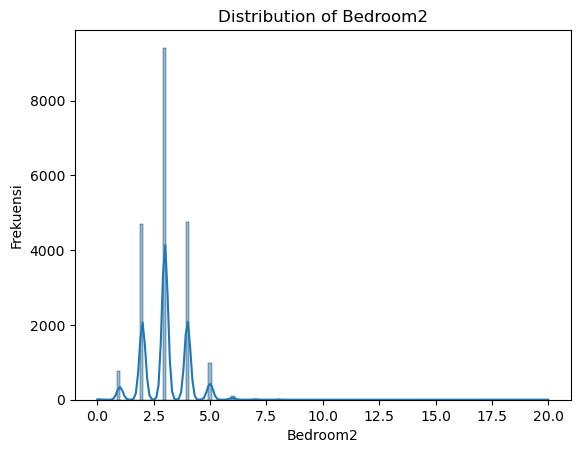

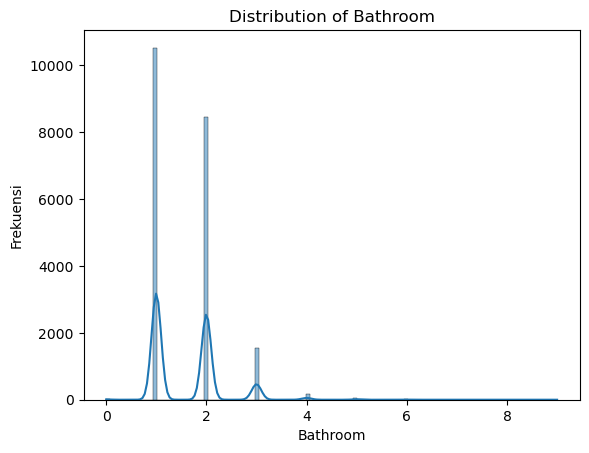

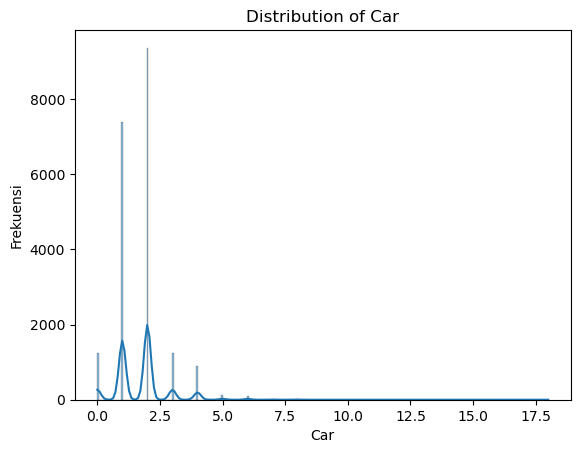

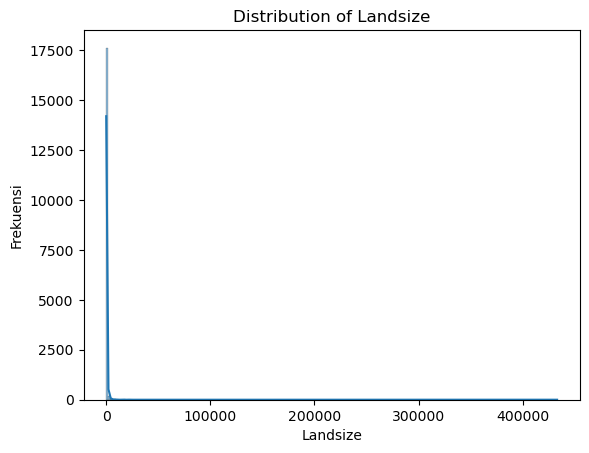

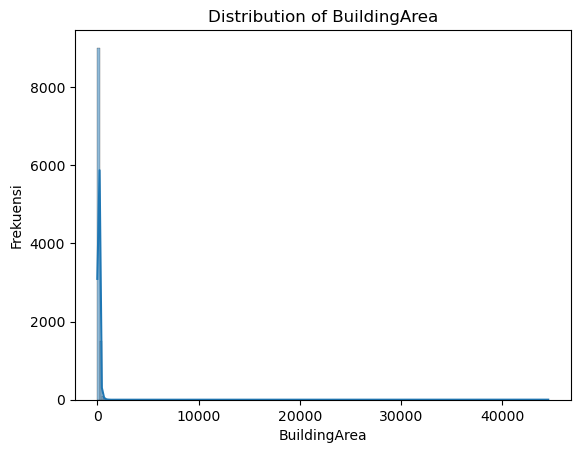

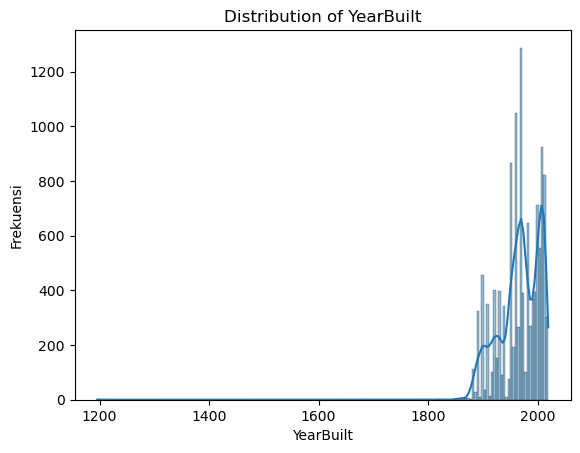

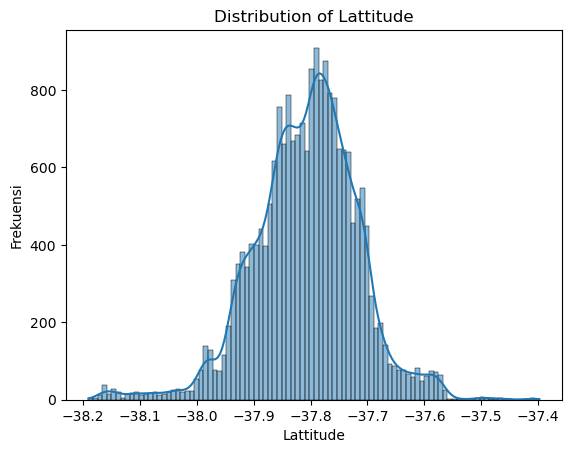

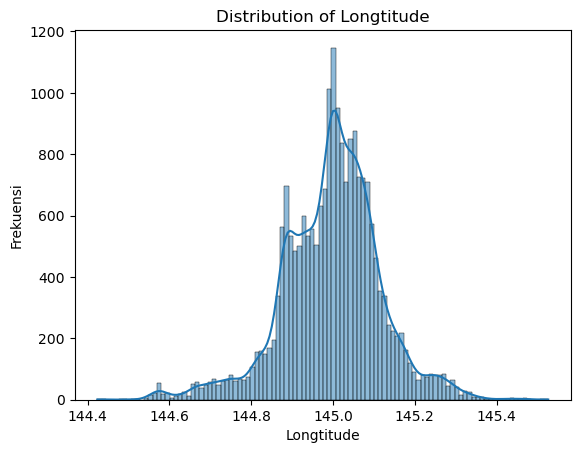

In [309]:
for col in cek_col:
    sns.histplot(data=df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

In [ ]:
col_great_20 = missing_pct[missing_pct >= 20].index
col_less_20 = missing_pct[missing_pct < 20].index
 
for col in col_great_20:
    if df_clean[col].isnull().sum() > 0:
        if abs(df_clean[col].skew()) > 1:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

Alasan:\
Imputasi dilakukan di semua kolom yang memiliki missing value lebih dari 20% karena data akan digunakan untuk training model

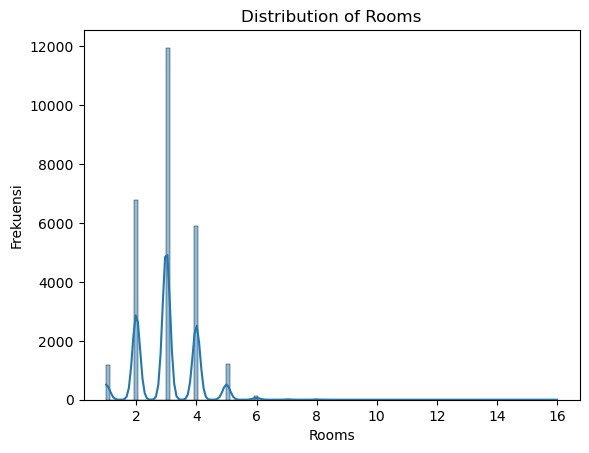

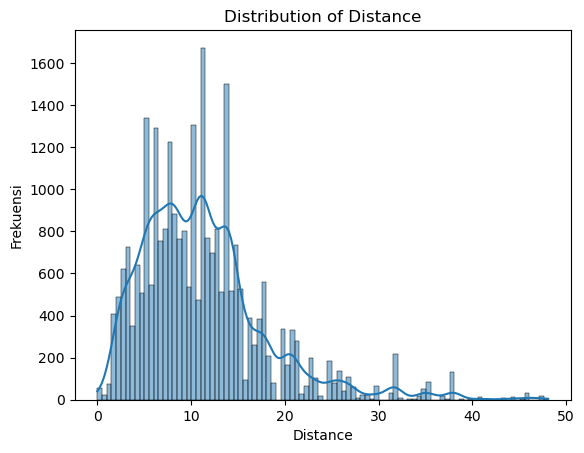

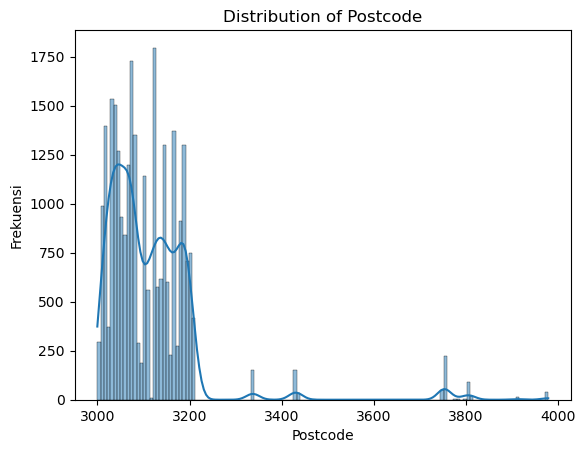

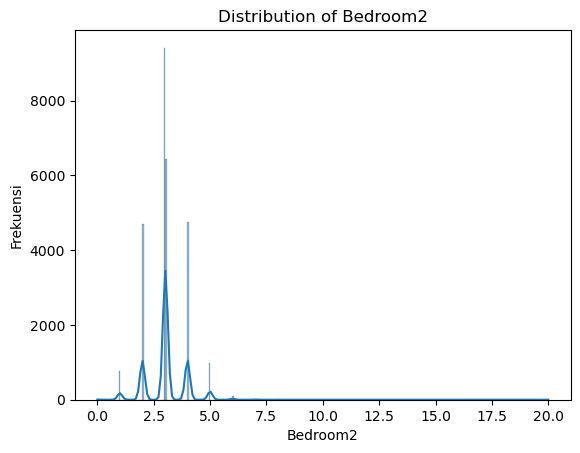

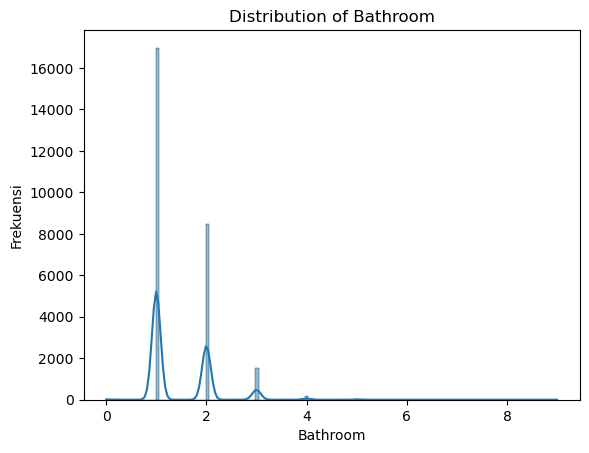

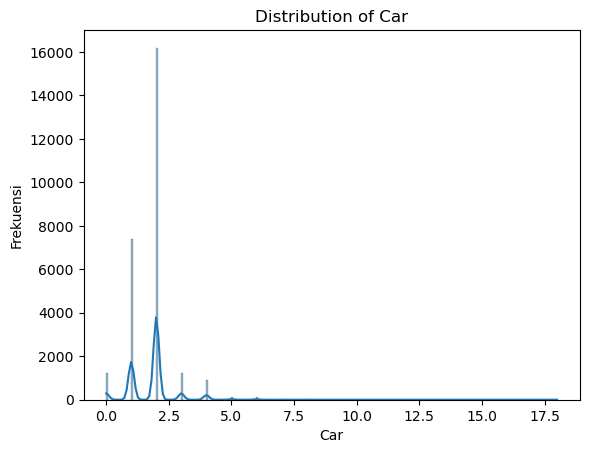

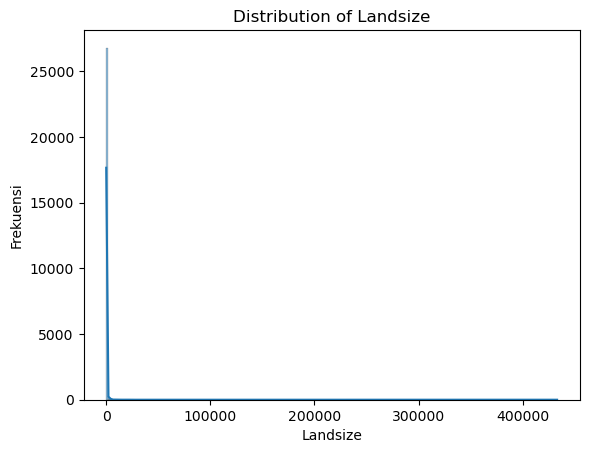

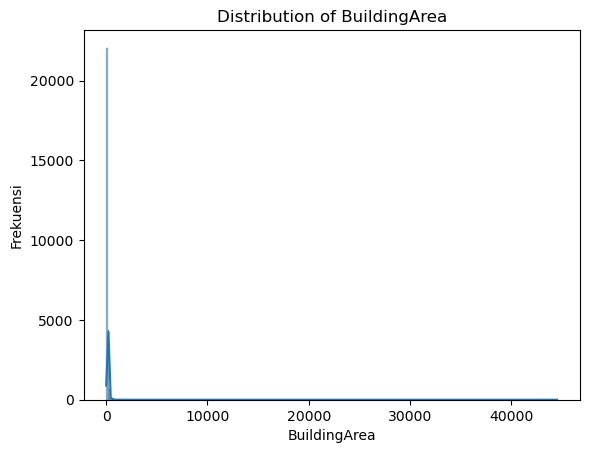

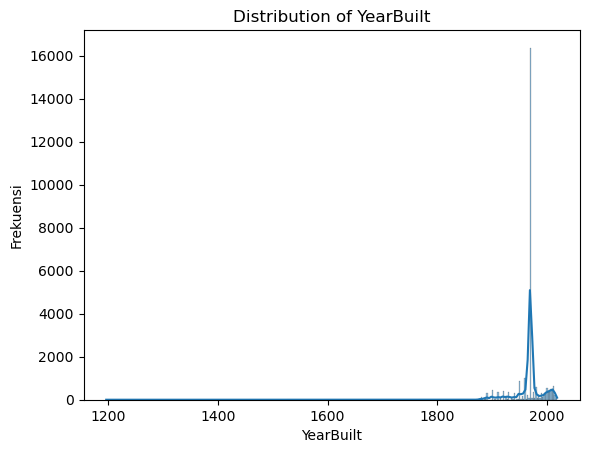

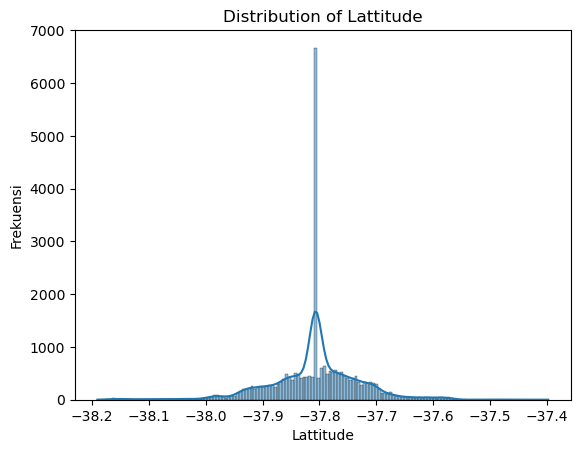

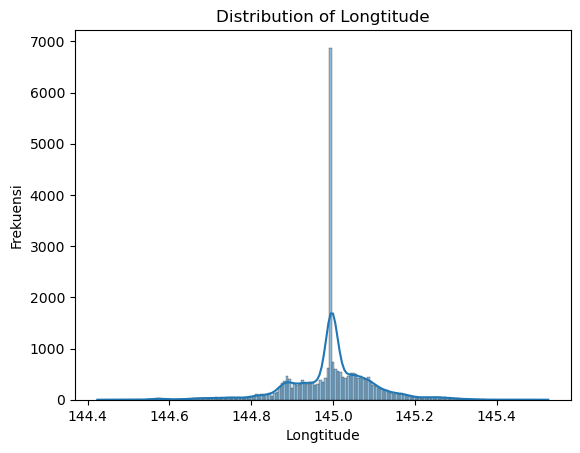

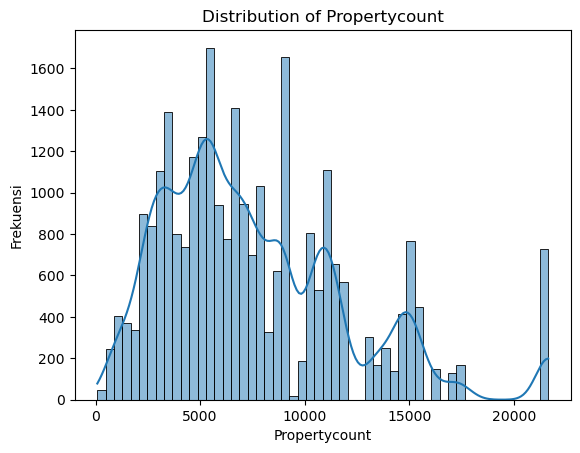

In [311]:
for col in df_clean.select_dtypes(include=["int64", "float64"]).drop(columns=["Price"]):
    sns.histplot(data=df_clean[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

In [ ]:
#Task 2.2 (Skip)

#Task 2.3
cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

#Task 2.4
df_clean.isna().sum().sum()

Propertycount    3
Distance         1
Postcode         1
Address          0
Suburb           0
Price            0
Type             0
Rooms            0
SellerG          0
Date             0
Bedroom2         0
Bathroom         0
Method           0
Car              0
Landsize         0
YearBuilt        0
BuildingArea     0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
dtype: int64

**Task 3 — Menangani High Cardinality**
1. Dari hasil audit Task 1, ambil kolom-kolom yang teridentifikasi sebagai high cardinality (contoh: Suburb, Address, SellerG).
2. Untuk kolom Suburb: terapkan FREQUENCY ENCODING. Hitung frekuensi kemunculan setiap nilai suburb, buat kolom baru Suburb_freq, lalu drop kolom Suburb asli.
3. Untuk kolom SellerG: terapkan TARGET ENCODING. Hitung rata-rata Price per SellerG, buat kolom baru SellerG_encoded, lalu drop kolom SellerG asli.
4. Drop kolom Address karena terlalu spesifik. Jelaskan alasannya di cell markdown (2 kalimat).
5. Untuk kolom kategorikal dengan kardinalitas rendah (di bawah 15 nilai unik, contoh: Type dan Method): terapkan One-Hot Encoding dengan pd.get_dummies dan drop_first=True.

In [313]:
#Task 3.1
high_cardinal = (
    df.select_dtypes(include='object')
    .nunique()
    .loc[lambda x : x > 15]
    .sort_values(ascending=False)
)

high_cardinal

D:\Users\bsi80267\AppData\Local\Temp\ipykernel_8352\909783481.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object')


Address        26751
SellerG          349
Suburb           345
Date              78
CouncilArea       33
dtype: int64

In [314]:
low_cardinal = (
    df.select_dtypes(include='object')
    .nunique()
    .loc[lambda x : x <= 15]
    .sort_values(ascending=False)
)

low_cardinal

D:\Users\bsi80267\AppData\Local\Temp\ipykernel_8352\2550287782.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object')


Regionname    8
Method        5
Type          3
dtype: int64

In [315]:
#Task 3.2
suburb_freq = df_clean["Suburb"].value_counts(normalize=True)
df_clean["Suburb_freq"] = df_clean["Suburb"].map(suburb_freq)

df_clean.drop(columns=["Suburb"], inplace=True)

In [316]:
#Task 3.3
seller_price_mean = df_clean.groupby("SellerG")["Price"].mean()

df_clean["SellerG_encoded"] = df_clean["SellerG"].map(seller_price_mean)
df_clean.drop(columns=["SellerG"], inplace=True)

In [317]:
#Task 3.4
df_clean.drop(columns=["Address"], inplace=True)

Alasan:\
Address tidak digunakan karena bentuk datanya terlalu spesifik, sehingga jika di lakukan encoding tidak akan memberikan pola generalisasi. Selain itu, dapat meningkatkan resiko overfitting.

In [ ]:
#Task 3.5
df_clean = pd.get_dummies(df_clean, columns=low_cardinal.index.tolist(), drop_first=True)


In [319]:
df_semi = df_clean.copy()
df_semi = df_semi.dropna()

In [320]:
X_semi = df_semi.select_dtypes(include=["int64", "float64"]).drop(columns=["Price"])
y_semi = df_semi["Price"]

score2 = cross_val_score(model1, X_semi, y_semi, cv=5, scoring='r2')

print('')
print('Skor Missing + Cardinality')
print(f'Mean R2 (5 fold): {score2.mean()}')
print(f'STD R2 (5 fold): {score2.std()}')


Skor Missing + Cardinality
Mean R2 (5 fold): 0.5071348400222966
STD R2 (5 fold): 0.06534603401817907


**Task 4 — Deteksi dan Penanganan Outlier**
1. Buat boxplot untuk kolom Price, Landsize, dan BuildingArea dalam satu figure (subplot 1x3). Amati keberadaan outlier.
2. Hitung batas outlier kolom Price menggunakan metode IQR: Q1 = 25th percentile, Q3 = 75th percentile, IQR = Q3 - Q1, Lower bound = Q1 - 1.5 x IQR, Upper bound = Q3 + 1.5 x IQR. Cetak jumlah baris yang termasuk outlier.
3. Terapkan CAPPING pada kolom Price: ganti nilai di bawah lower bound dengan lower bound, dan nilai di atas upper bound dengan upper bound.
4. Untuk kolom Landsize, terapkan metode Z-Score (batas: |z| lebih dari 3). Cetak jumlah outlier yang terdeteksi, lalu terapkan TRIMMING: hapus baris dengan z-score di luar batas tersebut.
5. Buat ulang boxplot untuk Price dan Landsize setelah penanganan dalam satu figure (subplot 1x2) dengan judul "Setelah Penanganan Outlier".

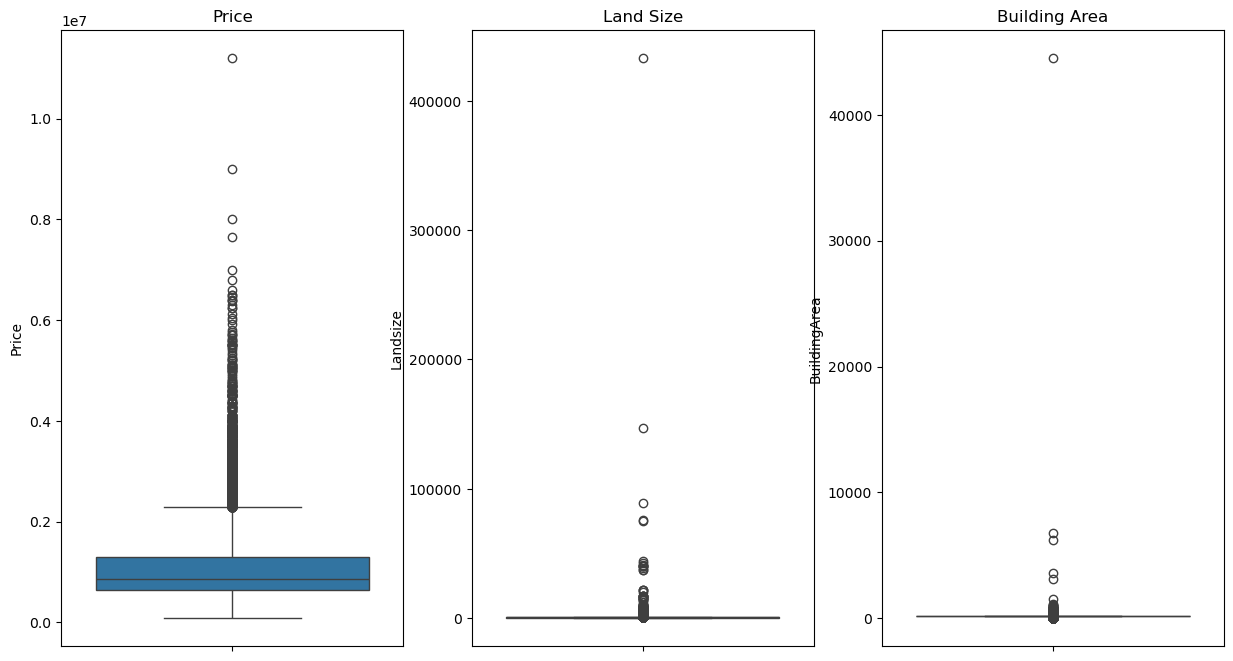

In [321]:
#Task 4.1
fig, axes = plt.subplots(1, 3, figsize=(15,8))

sns.boxplot(y=df_clean['Price'], ax=axes[0])
sns.boxplot(y=df_clean['Landsize'], ax=axes[1])
sns.boxplot(y=df_clean['BuildingArea'], ax=axes[2])

axes[0].set_title('Price')
axes[1].set_title('Land Size')
axes[2].set_title('Building Area')

plt.show()

In [322]:
#Task 4.2
q1 = df_clean['Price'].quantile(0.25)
q3 = df_clean['Price'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers_price = ((df_clean["Price"] < lower) | (df_clean["Price"] > upper)).sum()
outliers_price


np.int64(1278)

In [323]:
#Task 4.3
df_clean['Price'] = np.clip(df_clean['Price'], lower, upper)

In [324]:
df_clean.shape

(27247, 30)

In [325]:
#Task 4.4
skor_pembanding_z = 0.0176

z_score = np.abs(zscore(df_clean['Price']))

df_clean = df_clean[z_score <= skor_pembanding_z]

Text(0.5, 1.0, 'Land Size Setelah Penanganan')

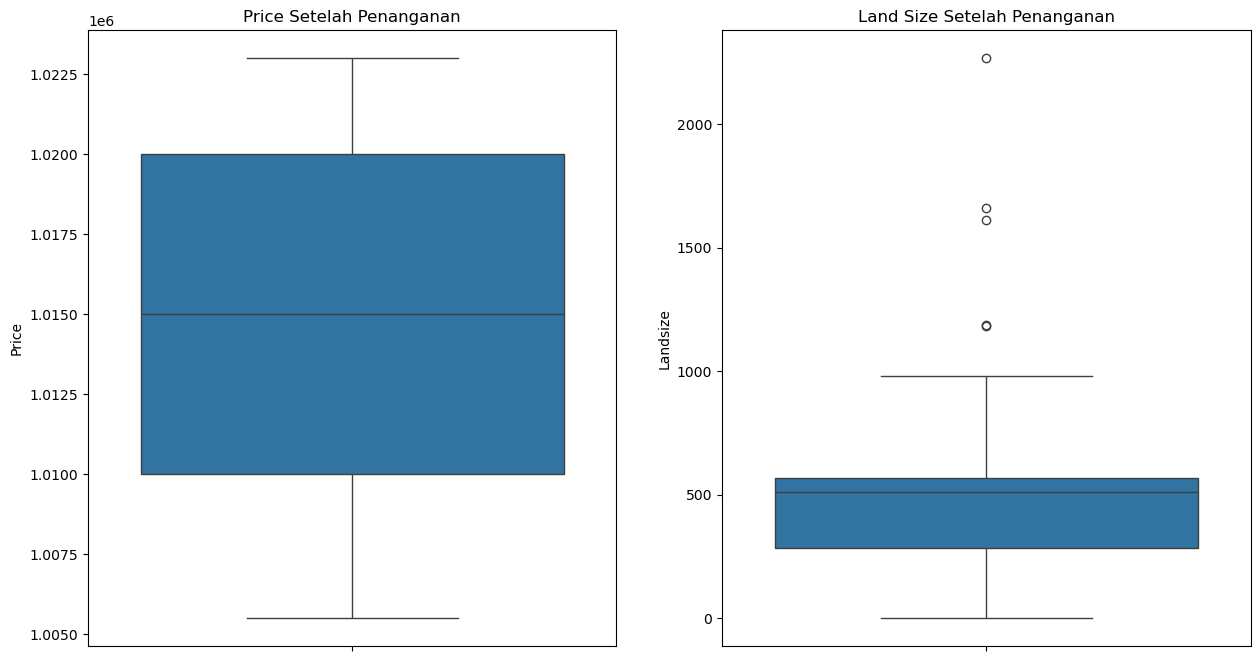

In [326]:
fig, axes = plt.subplots(1, 2, figsize=(15,8))

sns.boxplot(y=df_clean['Price'], ax=axes[0])
sns.boxplot(y=df_clean['Landsize'], ax=axes[1])

axes[0].set_title('Price Setelah Penanganan')
axes[1].set_title('Land Size Setelah Penanganan')

**Task 5 — Evaluasi Akhir dan Perbandingan**
1. Siapkan X_final dari df_clean setelah semua penanganan. Gunakan hanya kolom numerik. Drop kolom non-numerik yang tersisa.
2. Latih LinearRegression dengan 5-fold CV (scoring='r2') pada X_final. Cetak skor rata-rata dan standar deviasinya.
3. Buat tabel ringkasan di cell markdown yang membandingkan tiga tahap: Baseline, Setelah handle missing + cardinality, dan Setelah + handle outlier (final).
4. Tulis 4 sampai 5 kalimat analisis: langkah mana yang paling berdampak pada skor R2? Apakah ada langkah yang justru menurunkan skor? Jika ya, berikan hipotesis mengapa.

In [327]:
#Task 5.1
X_final = df_clean.select_dtypes(include=["int64", "float64"]).drop(columns=["Price"])
y_final = df_clean["Price"]


In [ ]:
#Task 5.2
score3 = cross_val_score(model1, X_final, y_final, cv=5, scoring='r2')

print('')
print('Skor Final')
print(f'Mean R2 (5 fold): {score3.mean()}')
print(f'STD R2 (5 fold): {score3.std()}')


Skor Final
Mean R2 (5 fold): -0.12611621625479322
STD R2 (5 fold): 0.09937338382231373


**#Task 5.3**
| Model | R2 Mean | R2 STD |
|-------|---------|--------|
| Baseline | -0.083 |  0.616 |
| Missing + Cadinality | 0.507 | 0.065 |
| Final | -0.126 | 0.099 |

**#Task 5.4**\
Sesuai dengan hasil di atas, penanganan missing values dan kardinalitas dapat meningkatkan hasil R2 paling signifikan karena menambahkan banyak fitur sebagai konsiderasi pengambilan keputusan model. Frequency Encoding dan Target Encoding membantu membuat kategori tanpa menghancurkan dimensi dari dataframe. Penanganan outlier tentu saja dilakukan untuk mengurangi variance dan meningkatkan stabilitas model, meskipun pada trimming hanya terjadi sedikit saja. Tapi secara keseluruhan model final dapat melakukan generalisasi.